# LINEAR REGRESSION


## Least Mean Squares : 

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('boston.csv')
df.head(50)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


In [44]:
df = df.drop(columns = 'CHAS') # Don't think to be valueable

In [45]:
df


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [46]:
x_test = df.drop(columns = 'MEDV')[450:]
y_test = df['MEDV'][450:]
x_train = df.drop(columns = 'MEDV')[:450]
y_train = df['MEDV'][:450]

### Normalization:

In [47]:
# x_mean = []
# x_std = []
# for cols in x_train.columns:
#     x_mean.append(x_train[cols].mean())
#     x_std.append(x_train[cols].std())
# x_mean = pd.Series(x_mean)
# x_std = pd.Series(x_std)
# for cols in x_train.columns:
#     x_train[cols] = (x_train[cols] - x_train[cols].mean())/x_train[cols].std()
# x_train.head(50)
x_train1 = x_train
means = x_train1.mean()
stds  = x_train1.std()
  
for col in x_train1.columns:
    x_train1[col] = (x_train1[col] - means[col]) / stds[col]

for col in x_test.columns:
    x_test[col] = (x_test[col] - means[col]) / stds[col]
x_train1


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.388529,0.214330,-1.201255,-0.073145,0.377263,-0.073106,0.069737,-0.934781,-0.567488,-1.337587,0.434773,-1.004311
1,-0.386198,-0.524425,-0.492813,-0.654789,0.164704,0.399673,0.471304,-0.810951,-0.912133,-0.203441,0.434773,-0.436898
2,-0.386201,-0.524425,-0.492813,-0.654789,1.219216,-0.214595,0.471304,-0.810951,-0.912133,-0.203441,0.388225,-1.133888
3,-0.385637,-0.524425,-1.220603,-0.747515,0.961109,-0.742589,0.972678,-0.687121,-1.039780,0.204852,0.408811,-1.282561
4,-0.381563,-0.524425,-1.220603,-0.747515,1.166766,-0.452710,0.972678,-0.687121,-1.039780,0.204852,0.434773,-0.956572
...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.795811,-0.524425,1.148806,1.629640,0.217153,0.948372,-0.892676,1.913316,1.793972,0.885340,-3.612052,1.587236
446,0.309023,-0.524425,1.148806,1.629640,0.054284,1.003587,-0.854172,1.913316,1.793972,0.885340,-0.467482,0.742937
447,0.712867,-0.524425,1.148806,1.629640,-0.069939,1.010489,-0.796485,1.913316,1.793972,0.885340,0.338932,0.558801
448,0.646711,-0.524425,1.148806,1.402040,-0.161035,1.082959,-0.767367,1.913316,1.793972,0.885340,0.434773,0.789312


In [48]:
for cols in x_train.columns:
    x_train[cols] = (x_train[cols] - x_train[cols].mean())/x_train[cols].std()
x_train.head(50)

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.388529,0.214330,-1.201255,-0.073145,0.377263,-0.073106,0.069737,-0.934781,-0.567488,-1.337587,0.434773,-1.004311
1,-0.386198,-0.524425,-0.492813,-0.654789,0.164704,0.399673,0.471304,-0.810951,-0.912133,-0.203441,0.434773,-0.436898
2,-0.386201,-0.524425,-0.492813,-0.654789,1.219216,-0.214595,0.471304,-0.810951,-0.912133,-0.203441,0.388225,-1.133888
3,-0.385637,-0.524425,-1.220603,-0.747515,0.961109,-0.742589,0.972678,-0.687121,-1.039780,0.204852,0.408811,-1.282561
4,-0.381563,-0.524425,-1.220603,-0.747515,1.166766,-0.452710,0.972678,-0.687121,-1.039780,0.204852,0.434773,-0.956572
5,-0.385916,-0.524425,-1.220603,-0.747515,0.177126,-0.297417,0.972678,-0.687121,-1.039780,0.204852,0.402978,-0.972939
6,-0.379427,-0.011401,-0.373748,-0.191160,-0.399819,-0.024793,0.742982,-0.439460,-0.471753,-1.382953,0.419905,0.011848
7,-0.373180,-0.011401,-0.373748,-0.191160,-0.178979,0.993234,0.921538,-0.439460,-0.471753,-1.382953,0.434773,0.928438
8,-0.365774,-0.011401,-0.373748,-0.191160,-0.925695,1.127821,0.981789,-0.439460,-0.471753,-1.382953,0.317316,2.398799
9,-0.370349,-0.011401,-0.373748,-0.191160,-0.410861,0.641238,1.215284,-0.439460,-0.471753,-1.382953,0.318231,0.648823


#### Batch Gradient Descent:

In [49]:
x_train['ONE'] = 1
x_train1['ONE'] = 1
x_test['ONE'] = 1
x_train1

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,ONE
0,-0.388529,0.214330,-1.201255,-0.073145,0.377263,-0.073106,0.069737,-0.934781,-0.567488,-1.337587,0.434773,-1.004311,1
1,-0.386198,-0.524425,-0.492813,-0.654789,0.164704,0.399673,0.471304,-0.810951,-0.912133,-0.203441,0.434773,-0.436898,1
2,-0.386201,-0.524425,-0.492813,-0.654789,1.219216,-0.214595,0.471304,-0.810951,-0.912133,-0.203441,0.388225,-1.133888,1
3,-0.385637,-0.524425,-1.220603,-0.747515,0.961109,-0.742589,0.972678,-0.687121,-1.039780,0.204852,0.408811,-1.282561,1
4,-0.381563,-0.524425,-1.220603,-0.747515,1.166766,-0.452710,0.972678,-0.687121,-1.039780,0.204852,0.434773,-0.956572,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.795811,-0.524425,1.148806,1.629640,0.217153,0.948372,-0.892676,1.913316,1.793972,0.885340,-3.612052,1.587236,1
446,0.309023,-0.524425,1.148806,1.629640,0.054284,1.003587,-0.854172,1.913316,1.793972,0.885340,-0.467482,0.742937,1
447,0.712867,-0.524425,1.148806,1.629640,-0.069939,1.010489,-0.796485,1.913316,1.793972,0.885340,0.338932,0.558801,1
448,0.646711,-0.524425,1.148806,1.402040,-0.161035,1.082959,-0.767367,1.913316,1.793972,0.885340,0.434773,0.789312,1


In [26]:
n = 13
m  = 450
theta = np.zeros((n,1),dtype = np.float64)
theta


array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

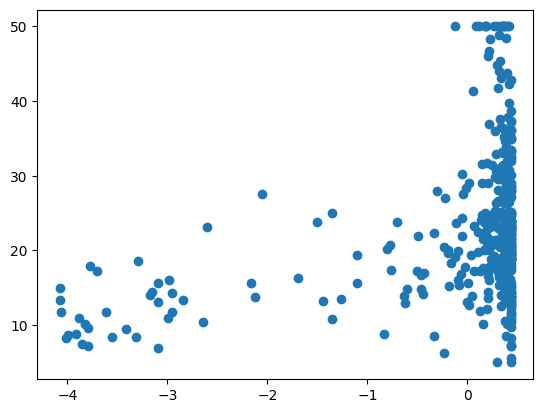

In [59]:
alpha = 0.001
e = 0.001
x_train = np.array(x_train)
y_train = np.array(y_train)
plt.scatter(x_train[:,10],y_train)
plt.show()

In [28]:
J_initial = 0
for i in range(m):
    z = np.dot((theta.T), x_train[i,:])
    z -= y_train[i]
    J_initial += (z*z)
J_initial = J_initial/ (2*m)
J_initial


array([310.64991111])

In [29]:
j_old = 0
j_new = J_initial
num_iter = 0
while abs(j_old - j_new) > e :

    #gradient descent:
    theta1 = np.zeros((n,1))
    for j in range(n):
        grad = 0
        for i in range(m):
            grad += ((np.dot((theta.T),x_train[i,:]) - y_train[i])*x_train[i,j])
        grad = grad*alpha
        theta1[j] = theta[j] - (grad/m)
    theta = theta1
    J = 0
    for i in range(m):
        z = np.dot((theta.T), x_train[i,:])
        z -= y_train[i]
        J += (z*z)
    J /= (2*m)
    j_old = j_new
    j_new = J
    if(j_old < j_new):
        print('Mistake in alpha!!')
        break
    if ((num_iter % 1000 )== 0):
        print(f"Iteration {num_iter}:  {j_new} ")
    num_iter+=1
print(j_new,j_old)
theta

Iteration 0:  [309.88500411] 
Iteration 1000:  [50.69888772] 
Iteration 2000:  [17.94255878] 
Iteration 3000:  [13.33720474] 
[13.00962763] [13.0106274]


array([[-0.74950659],
       [ 0.56575306],
       [-0.31540667],
       [-0.68098924],
       [ 3.51149118],
       [ 0.05548563],
       [-1.92149744],
       [ 0.69868576],
       [-0.52253162],
       [-1.79932938],
       [ 0.88588034],
       [-3.49081992],
       [22.16127523]])

testing

In [30]:
x_test = np.array(x_test)
y_test = np.array(y_test)
cost_test = 0
for i in range(x_test.shape[0]):
    z = (np.dot((theta.T),x_test[i,:]) - y_test[i])**2
    cost_test += z
cost_test = cost_test/ (2*x_test.shape[0])
cost_test

array([4.97795697])

## Normal Equation

In [31]:
df.drop_duplicates()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [32]:
x_train = df.drop(columns = 'MEDV')[:450]
y_train = df["MEDV"][:450]
x_test = df.drop(columns = 'MEDV')[450:]
y_test = df['MEDV'][450:]
means = x_train.mean()
std = x_train.std()
for cols in x_train.columns:
    x_train[cols] = (x_train[cols] - x_train[cols].mean())/x_train[cols].std()
for cols in x_test.columns:
    x_test[cols] = (x_test[cols] - means[cols])/std[cols]
x_train.shape

(450, 12)

In [33]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
n = x_train.shape[1]
m = x_train.shape[0]
theta = np.zeros((n,1))

In [34]:
z = np.linalg.inv(np.dot((x_train.T),x_train))
y = np.dot((x_train.T),y_train)
theta = np.dot(z,y)
theta
cost_test = 0

In [35]:
for i in range(x_test.shape[0]):
    z = (np.dot((theta.T),x_test[i,:]) - y_test[i])**2
    cost_test += z
cost_test = cost_test/ (2*x_test.shape[0])
cost_test

np.float64(250.13629013766487)

In [36]:
# ChatGPT
# Convert to numpy
x_train = np.array(x_train)
x_test  = np.array(x_test)
y_train = np.array(y_train).reshape(-1, 1)
y_test  = np.array(y_test).reshape(-1, 1)

# Add bias term
x_train = np.c_[np.ones((x_train.shape[0], 1)), x_train]
x_test  = np.c_[np.ones((x_test.shape[0], 1)), x_test]

# Normal equation (stable)
theta = np.linalg.pinv(x_train) @ y_train

# Test cost
y_pred = x_test @ theta
cost_test = np.mean((y_pred - y_test)**2) / 2
cost_test = cost_test.item()

print(cost_test)


6.178907728375202
